In [25]:
import requests
from dotenv import load_dotenv
import os

# Configurare din .env [cite: 60]
load_dotenv()

CLIENT_ID = os.getenv("CLIENT_ID")
CLIENT_SECRET = os.getenv("CLIENT_SECRET")

def get_token():
    auth_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
    data = {
        "grant_type": "client_credentials",
        "client_id": CLIENT_ID,
        "client_secret": CLIENT_SECRET
    }
    response = requests.post(auth_url, data=data)
    return response.json()["access_token"]

def get_soil_moisture_data(bbox, startDate, endDate):
    token = get_token()
    url = "https://sh.dataspace.copernicus.eu/api/v1/process"
    
    # Evalscript: Calculează umiditatea brută din Sentinel-1 GRD [cite: 97, 109]
    evalscript = """
    //VERSION=3
    function setup() {
      return {
        input: ["VV"],
        output: { bands: 1, sampleType: "FLOAT32" }
      };
    }
    function evaluatePixel(samples) {
  if (samples.VV <= 0) return [NaN];
  return [10 * Math.log10(samples.VV)];
}
    """

    headers = {
        "Authorization": f"Bearer {token}",
    }

    payload = {
    "input": {
        "bounds": {
            "properties": {"crs": "http://www.opengis.net/def/crs/OGC/1.3/CRS84"},
            "bbox": bbox
        },
        "data": [{
            "type": "S1GRD",
            "dataFilter": {
                "timeRange": {
                    "from": startDate,
                    "to": endDate
                },
                "mosaickingOrder": "mostRecent"
            }
        }]
    },
    "output": {
        "responses": [{"format": {"type": "image/tiff"}}]
    },
    "evalscript": evalscript
}

    response = requests.post(url, headers=headers, json=payload)
    return response.content

------------------------------
REZULTAT ANALIZĂ FLOODWISE:
Umiditate Medie Sol: 75.80%
------------------------------


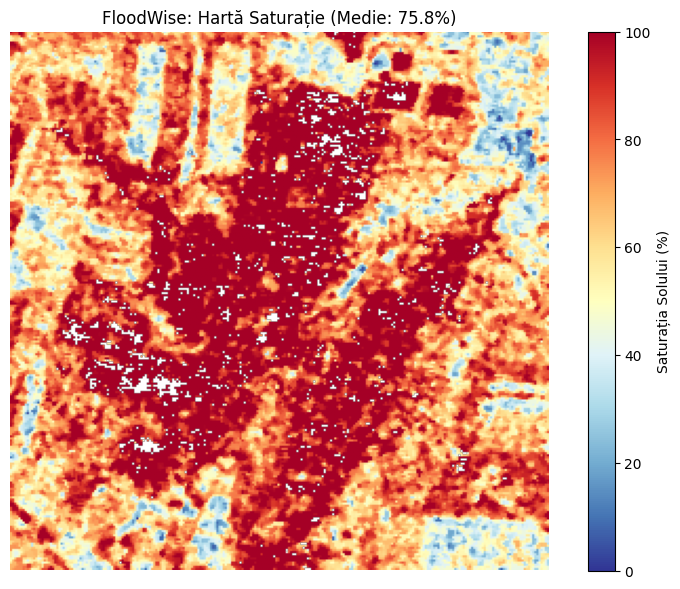

In [26]:

# Format expected by get_soil_moisture_data -> [min_lon, min_lat, max_lon, max_lat]
bbox = [27.773266, 45.603116, 27.817726, 45.649563]

from io import BytesIO
import numpy as np
import rasterio
from rasterio.io import MemoryFile
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage

# 1. Extragerea datelor brute
result = get_soil_moisture_data(bbox, "2026-04-20T00:00:00Z", "2026-04-20T23:59:59Z")

with MemoryFile(result) as memfile:
    with memfile.open() as src:
        arr = src.read(1).astype("float32")
        nodata = src.nodata
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)

# 2. Curățare și Filtrare (Speckle Filter)
# Ignorăm valorile extreme care nu sunt sol (clădiri/erori)
arr[~np.isfinite(arr)] = np.nan
arr[(arr < -30) | (arr > 0)] = np.nan

# Aplicăm un filtru median pentru a netezi "purecii" radar
arr_smooth = ndimage.median_filter(arr, size=3)

# 3. Transformare în Procent de Umiditate (SMI - Soil Moisture Index)
# Referințe standard pentru Sentinel-1 VV: -20dB (uscat) -> -8dB (saturat)
dry_ref = -20.0
wet_ref = -8.0

# Formula de normalizare
moisture_map = 100 * (arr_smooth - dry_ref) / (wet_ref - dry_ref)
moisture_map = np.clip(moisture_map, 0, 100) # Limităm între 0% și 100%

# 4. CALCULUL MEDIEI
# Ignorăm valorile NaN pentru o medie corectă
average_moisture = np.nanmean(moisture_map)

print("-" * 30)
print(f"REZULTAT ANALIZĂ FLOODWISE:")
print(f"Umiditate Medie Sol: {average_moisture:.2f}%")
print("-" * 30)

# 5. Vizualizare
valid = moisture_map[np.isfinite(moisture_map)]
vmin, vmax = np.percentile(valid, [2, 98])

plt.figure(figsize=(10, 7))
# Folosim RdYlBu_r: Roșu = Uscat, Albastru = Ud
plt.imshow(moisture_map, cmap="RdYlBu_r", vmin=0, vmax=100)
plt.colorbar(label="Saturația Solului (%)")
plt.title(f"FloodWise: Hartă Saturație (Medie: {average_moisture:.1f}%)")
plt.axis("off")
plt.show()